In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

In [2]:
def _show(image, ax):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

def show_encoding(img_1, img_2):
    ax1 = plt.subplot(1, 2, 1)
    _show(img_1, ax1)

    ax2 = plt.subplot(1, 2, 2)
    _show(img_2, ax2)
    
    plt.show()

In [3]:
# Load dataset
with np.load("../data/mnist.npz") as data:
    x_train_raw, y_train = data["x_train"], data["y_train"]
    x_test_raw, y_test = data["x_test"], data["y_test"]

# Preprocess for training
x_train = x_train_raw.reshape(-1, 28, 28, 1)/255.00
x_test  = x_test_raw.reshape(-1, 28, 28, 1)/255.00

In [9]:
# Cell 2
encoder_input = layers.Input(shape=(28,28,1))

x = layers.Conv2D(32,3,activation='relu',padding='same')(encoder_input)
x = layers.MaxPooling2D(2)(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2)(x)

x = layers.Flatten()(x)
x = layers.Dense(128,activation='relu')(x)

latent = layers.Dense(2, activation="linear")(x)

encoder = models.Model(encoder_input, latent)

encoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 420,610 (1.60 MB)

 Trainable params: 420,610 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Cell 3
decoder_input = layers.Input(shape=(2,))

x = layers.Dense(128,activation='relu')(decoder_input)
x = layers.Dense(7*7*64,activation='relu')(x)

x = layers.Reshape((7,7,64))(x)

x = layers.Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(x)
x = layers.Conv2DTranspose(32,3,strides=2,padding='same',activation='relu')(x)

decoder_output = layers.Conv2D(1,3,padding='same',activation='sigmoid')(x)

decoder = models.Model(decoder_input, decoder_output)

decoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3136)           │       404,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 460,609 (1.76 MB)

 Trainable params: 460,609 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Cell 4
autoencoder_input = encoder_input
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = models.Model(autoencoder_input, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
# Cell 5
history = autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.7994 - loss: 0.2689 - val_accuracy: 0.7948 - val_loss: 0.1974
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.7952 - loss: 0.1943 - val_accuracy: 0.7964 - val_loss: 0.1849
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.7963 - loss: 0.1852 - val_accuracy: 0.7979 - val_loss: 0.1809
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7975 - loss: 0.1811 - val_accuracy: 0.7994 - val_loss: 0.1783
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7982 - loss: 0.1786 - val_accuracy: 0.7990 - val_loss: 0.1765


In [ ]:
autoencoder.save("../models/autoencoder_2D.keras")
encoder.save("../models/encoder_2D.keras")

In [4]:
autoencoder = load_model("../models/autoencoder_2D.keras")
encoder = load_model("../models/encoder_2D.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


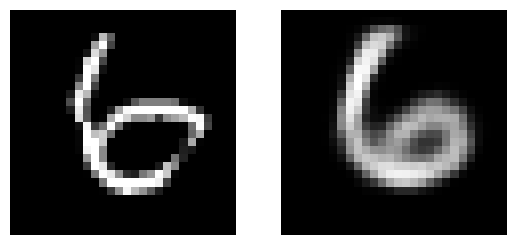

In [7]:
seed = np.random.randint(0, 60000)
img = x_train[seed].reshape(-1, 28, 28, 1)
pre_img = autoencoder.predict(img)
show_encoding(img.reshape(28, 28), pre_img.reshape(28, 28))

In [10]:
# Cell 6
latent_vectors = encoder.predict(x_train)

print(latent_vectors.shape)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
(60000, 2)


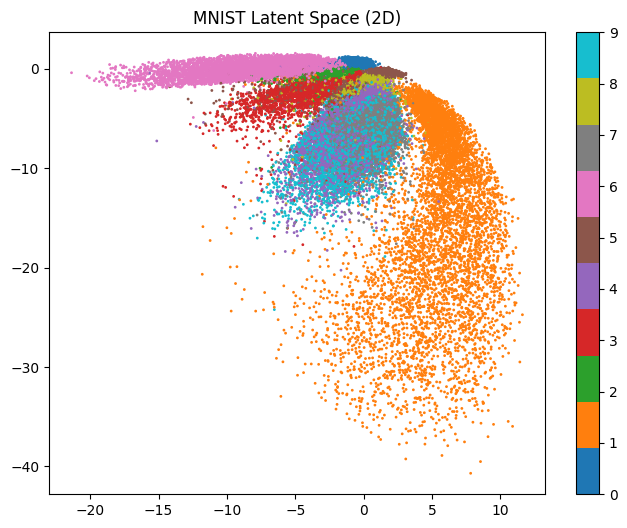

In [11]:
# Cell 7
plt.figure(figsize=(8,6))

plt.scatter(
    latent_vectors[:,0],
    latent_vectors[:,1],
    c=y_train,
    cmap="tab10",
    s=1
)

plt.colorbar()
plt.title("MNIST Latent Space (2D)")
plt.show()


In [8]:
mnist_classes = np.load("../data/mnist_classes.npz")
encode_mnist_clsses = [encoder.predict(mnist_classes[str(i)].reshape(-1, 28, 28, 1)/255.0)for i in range(10)]

184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


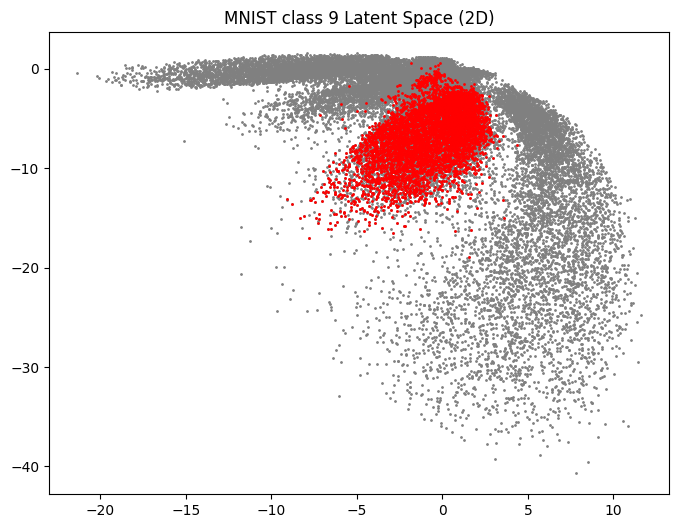

In [ ]:
_class = 9
plt.figure(figsize=(8,6))

plt.scatter(
    latent_vectors[:,0],
    latent_vectors[:,1],
    s=1,
    color="gray"
)

plt.scatter(
    encode_mnist_clsses[_class][:,0],
    encode_mnist_clsses[_class][:,1],
    s=1,
    color="red"
)
plt.title(f"MNIST class {_class} Latent Space (2D)")
plt.show()